<a href="https://colab.research.google.com/github/dhag/colab_demo/blob/main/HTTP_live_clicker_ngrok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ライブ・クリッカー（リアルタイム投票）/ Flask + ngrok

1つの公開URLに**全員のスマホ**からアクセスして投票 → **教卓の画面の棒グラフがリアルタイムに伸びる**デモです。

## 3つの画面
| URL | 役割 | 開く場所 |
|---|---|---|
| `/` | 学生用・投票ボタン | 学生のスマホ（QRから） |
| `/present` | 教卓用・ライブ棒グラフ | プロジェクタ |
| `/admin` | 出題・受付ON/OFF・集計リセット | 先生の手元 |

## ネットワークの学びどころ
- **共有ステート**：サーバ側の1つの集計を全クライアントで共有（`threading.Lock` で排他制御）。
- **サーバープッシュ（SSE）**：教卓画面は `text/event-stream` でサーバから push を受け、ポーリングなしで即時更新。
- **負荷の設計**：学生ページは軽量ポーリング、常時接続するSSEは台数の少ない教卓だけ、という住み分け（開発用サーバで教室規模に耐えさせる工夫）。

> 事前準備：ngrok 無料アカウントの authtoken（https://dashboard.ngrok.com/get-started/your-authtoken ）。上から順に実行し、最後のセルで出るQRを学生に見せます。

## ① 依存パッケージをインストール

In [1]:
!pip install -q flask pyngrok "qrcode[pil]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00


## ② Flask アプリを定義（投票API・3画面・SSE）

In [2]:
import json, threading, queue
from flask import Flask, request, Response

app = Flask(__name__)

# ------------ 全クライアントで共有する1つのステート ------------
lock = threading.Lock()
state = {
    "question": "今日の講義の難易度は？",
    "options":  ["やさしい", "ちょうどよい", "むずかしい"],
    "votes":    [0, 0, 0],
    "version":  0,      # 変化のたびに +1（クライアントの差分検知用）
    "open":     True,   # 投票受付中か
}
subscribers = []        # SSE 通知用のキュー一覧

def snapshot():
    with lock:
        return {
            "question": state["question"],
            "options":  list(state["options"]),
            "votes":    list(state["votes"]),
            "total":    sum(state["votes"]),
            "version":  state["version"],
            "open":     state["open"],
        }

def notify():
    data = json.dumps(snapshot(), ensure_ascii=False)
    for q in list(subscribers):
        try: q.put_nowait(data)
        except Exception: pass

# ============================ API ============================
@app.route("/vote", methods=["POST"])
def vote():
    idx = int(request.form.get("idx", -1))
    with lock:
        if not state["open"]:
            return {"ok": False, "reason": "closed"}, 403
        if not (0 <= idx < len(state["votes"])):
            return {"ok": False, "reason": "bad_idx"}, 400
        state["votes"][idx] += 1
        state["version"] += 1
    notify()
    return {"ok": True}

@app.route("/state")
def get_state():
    return snapshot()

@app.route("/set", methods=["POST"])
def set_q():
    q = request.form.get("question", "").strip()
    opts = [o.strip() for o in request.form.get("options", "").split("\n") if o.strip()]
    with lock:
        if q: state["question"] = q
        if len(opts) >= 2:
            state["options"] = opts
            state["votes"]   = [0] * len(opts)
        else:
            state["votes"]   = [0] * len(state["options"])
        state["open"] = True
        state["version"] += 1
    notify()
    return {"ok": True}

@app.route("/toggle", methods=["POST"])
def toggle():
    with lock:
        state["open"] = not state["open"]
        state["version"] += 1
    notify()
    return {"ok": True, "open": state["open"]}

@app.route("/reset", methods=["POST"])
def reset():
    with lock:
        state["votes"] = [0] * len(state["options"])
        state["version"] += 1
    notify()
    return {"ok": True}

# --- SSE: 教卓画面へサーバからリアルタイム push ---
@app.route("/stream")
def stream():
    def gen():
        q = queue.Queue()
        subscribers.append(q)
        try:
            yield f"data: {json.dumps(snapshot(), ensure_ascii=False)}\n\n"
            while True:
                try:
                    yield f"data: {q.get(timeout=15)}\n\n"
                except queue.Empty:
                    yield ": keepalive\n\n"   # コネクション維持
        finally:
            subscribers.remove(q)
    return Response(gen(), mimetype="text/event-stream")

## ③ 3つのHTML画面（学生 / 教卓 / 出題）

In [3]:
HEAD = """<!doctype html><html lang='ja'><head><meta charset='utf-8'>
<meta name='viewport' content='width=device-width,initial-scale=1'>
<style>
 *{box-sizing:border-box} body{font-family:system-ui,-apple-system,"Hiragino Kaku Gothic ProN",sans-serif;
   margin:0;background:#0f172a;color:#e2e8f0}
 .wrap{max-width:760px;margin:0 auto;padding:24px 18px}
 h1{font-size:1.5rem;margin:.2em 0 .6em}
 button{font-size:1.1rem;cursor:pointer;border:0;border-radius:12px}
 .opt{display:block;width:100%;padding:18px;margin:10px 0;background:#1e293b;color:#e2e8f0;
   border:1px solid #334155;text-align:left;transition:.15s}
 .opt:hover{background:#334155} .opt:active{transform:scale(.99)}
 .muted{color:#94a3b8} .big{font-size:2.2rem;font-weight:700}
 .bar{height:46px;border-radius:10px;background:#3b82f6;transition:width .6s cubic-bezier(.2,.8,.2,1);min-width:2px}
 .row{margin:14px 0} .lab{display:flex;justify-content:space-between;margin-bottom:6px;font-size:1.1rem}
 .pill{padding:4px 12px;border-radius:999px;background:#1e293b;border:1px solid #334155}
 textarea,input{width:100%;padding:10px;border-radius:10px;border:1px solid #334155;background:#1e293b;color:#e2e8f0;font-size:1rem}
 .btnrow button{padding:12px 18px;margin:6px 6px 0 0;background:#3b82f6;color:#fff}
 .btnrow .ghost{background:#1e293b;border:1px solid #334155;color:#e2e8f0}
</style></head><body><div class="wrap">"""
FOOT = "</div></body></html>"

# ---- 学生用：投票ボタン（軽量ポーリングで出題切替を検知） ----
@app.route("/")
def page_vote():
    return HEAD + """
    <h1 id="q">…</h1>
    <div id="opts"></div>
    <p id="msg" class="muted"></p>
    <script>
    let ver=-1, voted=false;
    async function load(){
      const s=await (await fetch('/state')).json();
      if(s.version!==ver){ ver=s.version; voted=false; render(s); }
      document.getElementById('msg').textContent =
        s.open ? (voted?'投票しました！結果は教卓画面で 🎉':'') : '受付は終了しました';
      if(!s.open) disable();
    }
    function render(s){
      document.getElementById('q').textContent=s.question;
      const box=document.getElementById('opts'); box.innerHTML='';
      s.options.forEach((o,i)=>{
        const b=document.createElement('button');
        b.className='opt'; b.textContent=o;
        b.onclick=()=>send(i); box.appendChild(b);
      });
    }
    function disable(){ document.querySelectorAll('.opt').forEach(b=>{b.disabled=true;b.style.opacity=.5;}); }
    async function send(i){
      const r=await fetch('/vote',{method:'POST',headers:{'Content-Type':'application/x-www-form-urlencoded'},
        body:'idx='+i});
      if(r.ok){ voted=true; disable(); document.getElementById('msg').textContent='投票しました！結果は教卓画面で 🎉'; }
      else { document.getElementById('msg').textContent='受付は終了しました'; disable(); }
    }
    load(); setInterval(load, 2500);
    </script>""" + FOOT

# ---- 教卓用：SSEでライブ棒グラフ ----
@app.route("/present")
def page_present():
    return HEAD + """
    <div class="lab"><span class="muted">LIVE 投票結果</span>
      <span class="pill">合計 <b id="total">0</b> 票</span></div>
    <h1 id="q">…</h1>
    <div id="bars"></div>
    <script>
    const palette=['#3b82f6','#22c55e','#eab308','#ef4444','#a855f7','#06b6d4','#f97316','#ec4899'];
    function render(s){
      document.getElementById('q').textContent=s.question;
      document.getElementById('total').textContent=s.total;
      const box=document.getElementById('bars'); box.innerHTML='';
      const max=Math.max(1,...s.votes);
      s.options.forEach((o,i)=>{
        const v=s.votes[i], pct=s.total? Math.round(v*100/s.total):0;
        const row=document.createElement('div'); row.className='row';
        row.innerHTML=`<div class="lab"><span>${o}</span><span class="muted">${v}票 / ${pct}%</span></div>
          <div class="bar" style="width:${(v/max*100)||2}%;background:${palette[i%palette.length]}"></div>`;
        box.appendChild(row);
      });
    }
    const es=new EventSource('/stream');
    es.onmessage=e=>render(JSON.parse(e.data));
    </script>""" + FOOT

# ---- 出題コントロール ----
@app.route("/admin")
def page_admin():
    return HEAD + """
    <h1>出題コントロール</h1>
    <p class="muted">問題（1行）と選択肢（改行区切り）を入力して「出題」</p>
    <input id="q" placeholder="問題文">
    <p></p>
    <textarea id="o" rows="5" placeholder="選択肢1&#10;選択肢2&#10;選択肢3"></textarea>
    <div class="btnrow">
      <button onclick="setq()">出題（集計リセット）</button>
      <button class="ghost" onclick="post('/toggle')">受付 ON / OFF</button>
      <button class="ghost" onclick="post('/reset')">集計だけリセット</button>
    </div>
    <p class="btnrow"><a href="/present" target="_blank" style="color:#60a5fa">▶ 教卓画面を開く</a>
       <a href="/" target="_blank" style="color:#60a5fa">▶ 学生画面を開く</a></p>
    <p id="msg" class="muted"></p>
    <script>
    async function setq(){
      const body=new URLSearchParams({question:document.getElementById('q').value,
                                      options:document.getElementById('o').value});
      await fetch('/set',{method:'POST',body});
      document.getElementById('msg').textContent='出題しました（集計リセット・受付ON）';
    }
    async function post(u){ const r=await fetch(u,{method:'POST'});
      document.getElementById('msg').textContent='OK: '+u; }
    </script>""" + FOOT

## ④ Flask をバックグラウンドで起動

In [4]:
import threading
PORT = 5000
def run():
    app.run(host="0.0.0.0", port=PORT, use_reloader=False, threaded=True)
threading.Thread(target=run, daemon=True).start()
print(f"Flask running on :{PORT}")

Flask running on :5000


## ⑤ ngrok で公開 ＋ QRコード表示
出てきた **QRを学生に見せる**だけで投票画面に入れます。
教卓では `/present`、先生の手元では `/admin` を開いてください。

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


ngrok authtoken を貼り付け（https://dashboard.ngrok.com/get-started/your-authtoken ）
··········
学生用（QR）   : https://6a54-34-12-61-157.ngrok-free.app/
教卓用（投影） : https://6a54-34-12-61-157.ngrok-free.app/present
出題（先生）   : https://6a54-34-12-61-157.ngrok-free.app/admin


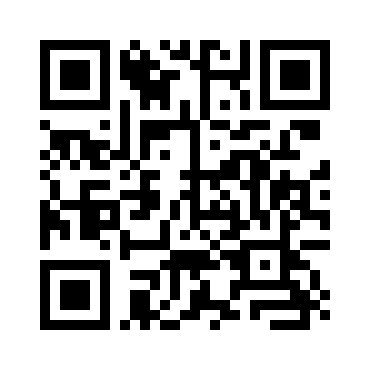

In [5]:
import getpass, qrcode, io
from pyngrok import ngrok, conf
from IPython.display import Image, display

print("ngrok authtoken を貼り付け（https://dashboard.ngrok.com/get-started/your-authtoken ）")
conf.get_default().auth_token = getpass.getpass()

# 既存トンネルを掃除してから公開（セル再実行対策）
for t in ngrok.get_tunnels():
    ngrok.disconnect(t.public_url)
public_url = ngrok.connect(PORT).public_url

print("=" * 56)
print("学生用（QR）   :", public_url + "/")
print("教卓用（投影） :", public_url + "/present")
print("出題（先生）   :", public_url + "/admin")
print("=" * 56)

# 学生に見せるQR
buf = io.BytesIO(); qrcode.make(public_url + "/").save(buf, "PNG")
display(Image(data=buf.getvalue()))

---
### メモ
- **ngrok 無料枠の警告ページ**：学生が初回アクセスで ngrok 確認ページを踏む場合は「Visit Site」。気になる場合は学生ページのfetchに `headers:{'ngrok-skip-browser-warning':'1'}` を足すと回避できる。
- **なぜ学生はポーリング／教卓はSSE？** 数十台が常時接続SSEを張ると開発用サーバが詰まりやすい。更新がリアルタイムで欲しいのは教卓の1〜2画面だけなので、そこをSSE、学生は2.5秒ごとの軽量ポーリングにしている（負荷設計の良い教材）。
- **集計はメモリ上**：notebook（カーネル）が落ちると消える。記録を残すなら `/vote` 内で CSV に追記すればよい。
- **発展**：選択肢を画像にする・自由記述を集めてワードクラウド・正解を設定してクイズ＆ランキング、など。